## Simple linear regression

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [41]:
df = pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


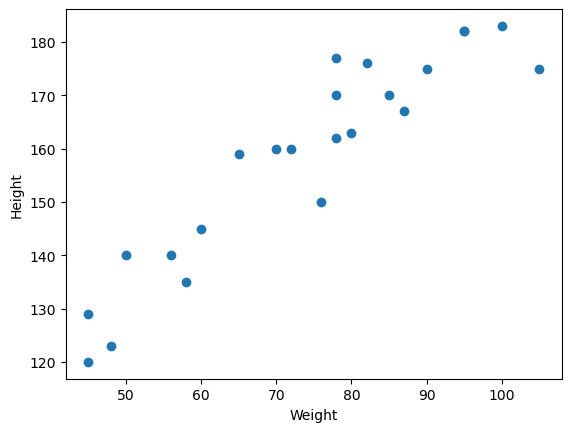

In [42]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

steps to follow:

1.divide the features based on independent and dependent features

2.Train test split

3.Standardizing the data

4.train the simple linear regression model

In [43]:
## divide the dataset
X = df[['Weight']] ## independent features
y = df['Height'] ## dependent features
print(X)
print(y)

    Weight
0       45
1       58
2       48
3       60
4       70
5       78
6       80
7       90
8       95
9       78
10      82
11      95
12     105
13     100
14      85
15      78
16      50
17      65
18      76
19      87
20      45
21      56
22      72
0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64


In [44]:
## 2.train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)


In [45]:
X.shape,X_train.shape,X_test.shape

((23, 1), (18, 1), (5, 1))

In [46]:
## 3.Standardization for independent data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train


array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

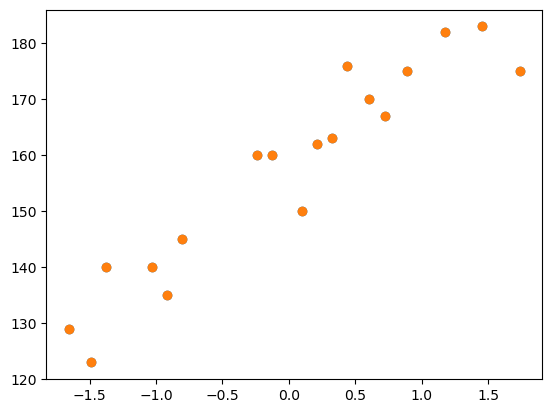

In [48]:
plt.scatter(X_train,y_train)
plt.show()

In [49]:
### train the simple lineare regression model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()


In [50]:
regressor.fit(X_train,y_train)

LinearRegression()

In [51]:
regressor.coef_

array([17.03440872])

In [52]:
regressor.intercept_

np.float64(157.5)

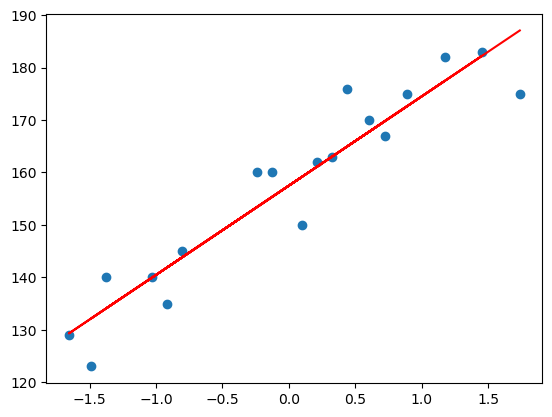

In [56]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')
plt.show()

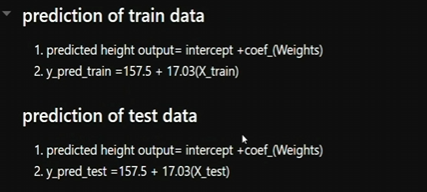

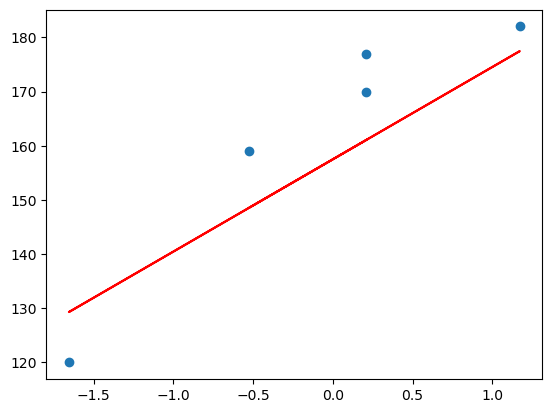

In [57]:
y_pred_test = regressor.predict(X_test)
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred_test,'r')
plt.show()

In [ ]:
### performnace metrics

## MSE,MAE,RMSE
## R sqaure , adjusted r sqaure

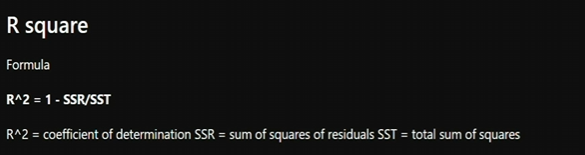

In [61]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
score = r2_score(y_test,y_pred_test)
print(mse)
print(mae)
print(rmse)
print(score)

109.77592599051664
9.822657814519232
10.477400726827081
0.776986986042344


## adjusted r square
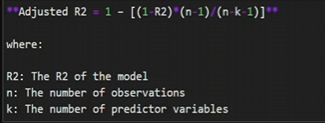

In [62]:
## raw data point weight is 80

scaled_weight = scaler.transform([[80]])
scaled_weight

c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [64]:
regressor.predict(scaled_weight)

array([163.01076266])

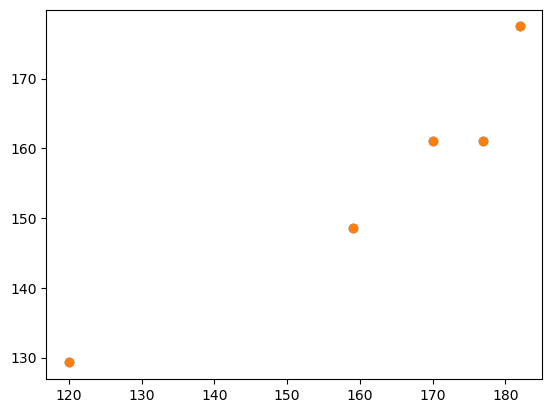

In [66]:
### assumptions 

## plot a scatter plot for the prediction 
plt.scatter(y_test,y_pred_test)
plt.show()

In [67]:
##residuals
residuals = y_test - y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

C:\Users\mayan\AppData\Local\Temp\ipykernel_30792\2754058692.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde = True)


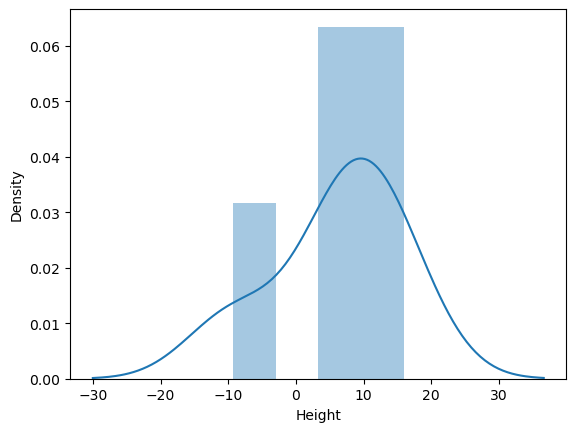

In [71]:
## plt these residuals
sns.distplot(residuals,kde = True)
plt.show()

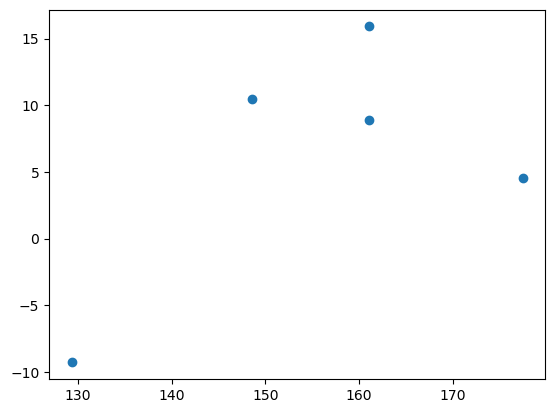

In [75]:
### unifor distributions
plt.scatter(y_pred_test,residuals)
plt.show()